# Phase 1: Predictive Model Development
## Predictive–Prescriptive–Explainable AI Framework for Web Performance Optimization

### Overview
This notebook implements the predictive modeling phase of the research project. It trains
machine learning models to classify website performance into three categories (fast / medium / slow)
based on Core Web Vitals and related metrics collected via Google PageSpeed Insights API.

### Dataset
- **Source**: `cleaned_website_performance_dataset_20251207_145008.csv` (885 URLs)
- Labels corrected using composite metrics (Response Time, LCP, FCP, Load Time, TTI, TBT)
- Missing values handled (hybrid strategy); outliers capped at 1.5×IQR
- 5 all-NaN columns dropped during preprocessing

### Methodology
1. **Data Loading & EDA** — distribution analysis, correlation heatmaps
2. **Preprocessing** — imputation, encoding, zero-variance removal
3. **Feature Engineering** — interaction terms, log transforms
4. **Model Training** — SVM, Random Forest, XGBoost with hyperparameter tuning via `RandomizedSearchCV`
5. **Evaluation** — accuracy, precision, recall, F1; confusion matrices; learning curves
6. **Cross-Validation** — `StratifiedKFold` inside `sklearn.Pipeline` (no data leakage)
7. **Statistical Significance** — McNemar's test for pairwise model comparison
8. **Model Export** — save best-performing model for Phase 2/3 consumption

## 1. Import Required Libraries

In [2]:
# Core libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

# Preprocessing & Pipelines
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold,
    RandomizedSearchCV, learning_curve
)
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Models
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    precision_recall_fscore_support
)

# Statistical testing
from scipy.stats import friedmanchisquare, wilcoxon

# Model persistence
import joblib
from datetime import datetime

print("All libraries imported successfully")
print(f"Pandas {pd.__version__} | NumPy {np.__version__}")

All libraries imported successfully
Pandas 2.3.3 | NumPy 2.3.5


## 2. Data Loading

In [3]:
def load_data(filepath='cleaned_website_performance_dataset_20251207_145008.csv'):
    """
    Load the website performance dataset.
    
    Parameters:
    -----------
    filepath : str
        Path to the CSV file
    
    Returns:
    --------
    pd.DataFrame
        Loaded dataset
    """
    df = pd.read_csv(filepath)
    print(f"Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
    print(f"\nColumns: {list(df.columns)}")
    print(f"\nDataset Info:")
    print(f"  Total URLs: {len(df)}")
    print(f"  Successful extractions: {df['extraction_successful'].sum() if 'extraction_successful' in df.columns else 'N/A'}")
    if 'extraction_successful' in df.columns:
        print(f"  Success rate: {df['extraction_successful'].sum() / len(df) * 100:.1f}%")
    print(f"\n✓ Using CLEANED dataset with fixed labels!")
    print(f"  Labels corrected using composite metrics")
    print(f"  Missing values handled systematically")
    print(f"  Outliers capped at 1.5*IQR")
    return df

# Load the cleaned 885-URL dataset with fixed labels
df = load_data()
df.head(10)

Dataset loaded successfully!
Shape: (885, 27)

Columns: ['Sr No', 'website_url', 'Category', 'Page Size (KB)', 'Load Time(s)', 'Response Time(s)', 'Throughput', 'Performance_Label', 'User Response', 'performance_score', 'lcp', 'fcp', 'cls', 'tti', 'tbt', 'speed_index', 'total_byte_weight', 'num_requests', 'dom_size', 'uses_text_compression', 'render_blocking_resources', 'unused_js', 'uses_http2', 'modern_image_formats', 'extraction_successful', 'error_message', 'extraction_timestamp']

Dataset Info:
  Total URLs: 885
  Successful extractions: 885
  Success rate: 100.0%

✓ Using CLEANED dataset with fixed labels!
  Labels corrected using composite metrics
  Missing values handled systematically
  Outliers capped at 1.5*IQR


,Sr No,website_url,Category,Page Size (KB),Load Time(s),Response Time(s),Throughput,Performance_Label,User Response,performance_score,...,num_requests,dom_size,uses_text_compression,render_blocking_resources,unused_js,uses_http2,modern_image_formats,extraction_successful,error_message,extraction_timestamp
0,0,https://www.booking.com/index.html?aid=1743217,Travel,3400.00,4.190,0.523,622.58,medium,Medium,62.0,...,163.0,NaN,NaN,NaN,0.0,NaN,NaN,True,NaN,2025-11-20 10:23:23
1,1,https://travelsites.com/expedia/,Travel,1331.20,1.040,0.350,20.00,fast,Fast,92.0,...,54.0,NaN,NaN,NaN,0.0,NaN,NaN,True,NaN,2025-11-20 10:23:41
2,2,https://travelsites.com/tripadvisor/,Travel,1945.60,0.833,0.392,331.29,fast,Medium,91.0,...,54.0,NaN,NaN,NaN,0.0,NaN,NaN,True,NaN,2025-11-20 10:24:00
3,3,https://www.momondo.in/?ispredir=true,Travel,13926.40,0.049,0.297,1.21,medium,Fast,37.0,...,127.0,NaN,NaN,NaN,0.0,NaN,NaN,True,NaN,2025-11-20 10:24:40
4,4,https://www.ebookers.com/?AFFCID=EBOOKERS-UK.n...,Travel,4300.80,0.751,1.211,61.45,slow,Medium,51.0,...,111.0,NaN,NaN,NaN,0.0,NaN,NaN,True,NaN,2025-11-20 10:25:12
5,6,https://www.trip.com/index?locale=en_us&allian...,Travel,1945.60,2.370,0.799,155.67,slow,Medium,48.0,...,242.0,NaN,NaN,NaN,0.0,NaN,NaN,True,NaN,2025-11-20 10:26:14
6,7,https://www.orbitz.com/,Travel,25209.15,1.000,2.099,54.79,medium,Medium,64.0,...,126.0,NaN,NaN,NaN,0.0,NaN,NaN,True,NaN,2025-11-20 10:26:55
7,8,https://www.travelocity.com/,Travel,0.00,0.000,1.220,97.47,slow,Fast,44.0,...,130.0,NaN,NaN,NaN,0.0,NaN,NaN,True,NaN,2025-11-20 10:27:38
8,9,https://www.hotwire.com/,Travel,2764.80,4.460,0.379,773.87,medium,Medium,51.0,...,138.0,NaN,NaN,NaN,0.0,NaN,NaN,True,NaN,2025-11-20 10:28:08
9,10,https://www.otel.com/,Travel,25209.15,0.531,1.135,88.36,fast,Medium,99.0,...,5.0,NaN,NaN,NaN,0.0,NaN,NaN,True,NaN,2025-11-20 10:28:20


## 3. Exploratory Data Analysis (EDA)

In [4]:
def perform_eda(df):
    """
    Perform comprehensive exploratory data analysis.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input dataset
    """
    print("="*80)
    print("EXPLORATORY DATA ANALYSIS")
    print("="*80)
    
    # Basic information
    print("\n1. DATASET INFO:")
    print("-"*80)
    df.info()
    
    # Statistical summary
    print("\n2. STATISTICAL SUMMARY:")
    print("-"*80)
    print(df.describe())
    
    # Missing values
    print("\n3. MISSING VALUES:")
    print("-"*80)
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    missing_df = pd.DataFrame({
        'Missing Count': missing,
        'Percentage': missing_pct
    })
    print(missing_df[missing_df['Missing Count'] > 0])
    
    # Target variable distribution
    print("\n4. TARGET VARIABLE DISTRIBUTIONS:")
    print("-"*80)
    if 'Performance_Label' in df.columns:
        print("\nPerformance_Label distribution:")
        print(df['Performance_Label'].value_counts())
        print(f"\nPercentages:")
        print(df['Performance_Label'].value_counts(normalize=True) * 100)
    
    if 'User Response' in df.columns:
        print("\nUser Response distribution:")
        print(df['User Response'].value_counts())
        print(f"\nPercentages:")
        print(df['User Response'].value_counts(normalize=True) * 100)
    
    # Data types
    print("\n5. DATA TYPES:")
    print("-"*80)
    print(df.dtypes)
    
    print("\n" + "="*80)

perform_eda(df)

EXPLORATORY DATA ANALYSIS

1. DATASET INFO:
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 885 entries, 0 to 884
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Sr No                      885 non-null    int64  
 1   website_url                885 non-null    object 
 2   Category                   885 non-null    object 
 3   Page Size (KB)             885 non-null    float64
 4   Load Time(s)               885 non-null    float64
 5   Response Time(s)           885 non-null    float64
 6   Throughput                 885 non-null    float64
 7   Performance_Label          885 non-null    object 
 8   User Response              885 non-null    object 
 9   performance_score          885 non-null    float64
 10  lcp                        885 non-null    float64
 11  fcp                        885 non-nu

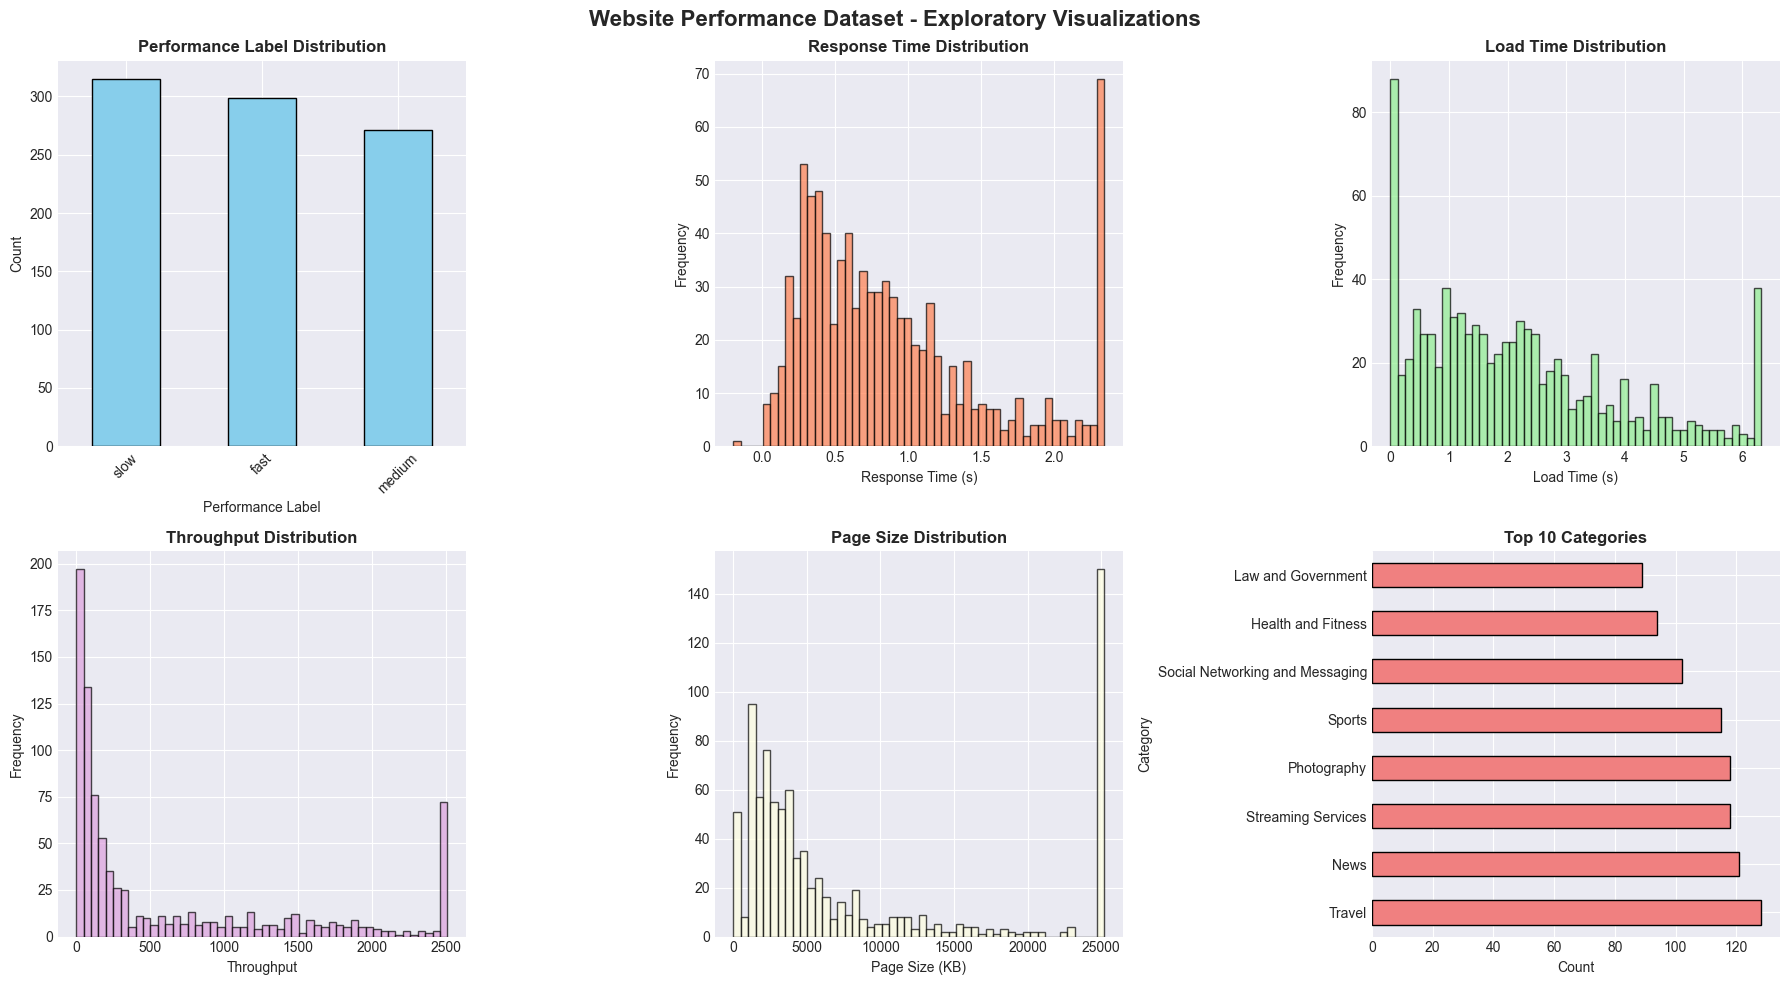

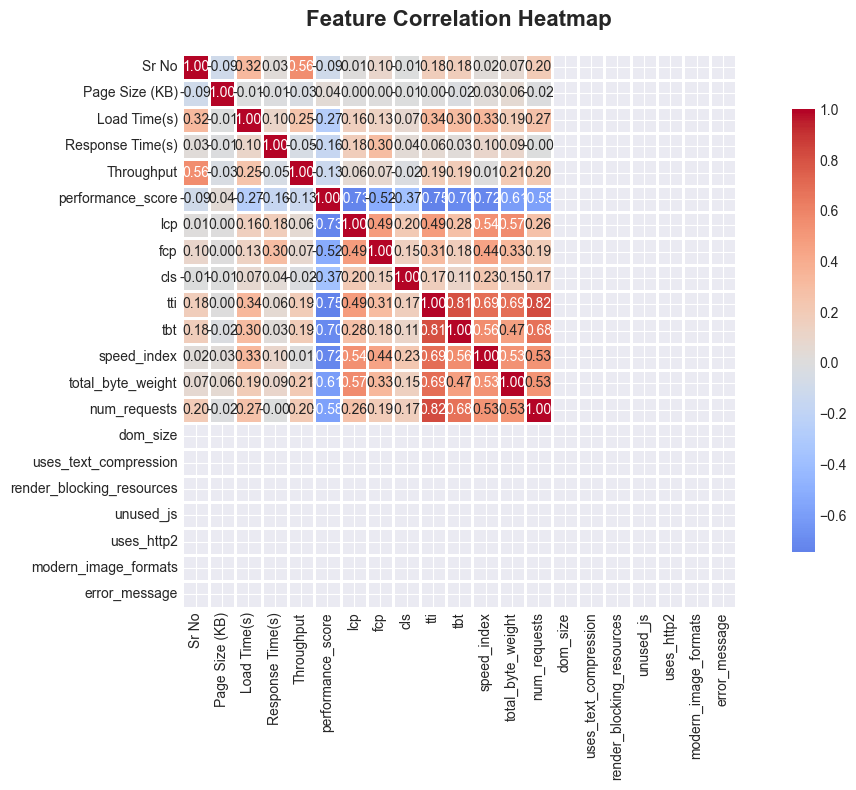

In [5]:
def visualize_data(df):
    """
    Create visualizations for data exploration.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input dataset
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Website Performance Dataset - Exploratory Visualizations', fontsize=16, fontweight='bold')
    
    # 1. Target variable distributions
    if 'Performance_Label' in df.columns:
        df['Performance_Label'].value_counts().plot(kind='bar', ax=axes[0, 0], color='skyblue', edgecolor='black')
        axes[0, 0].set_title('Performance Label Distribution', fontweight='bold')
        axes[0, 0].set_xlabel('Performance Label')
        axes[0, 0].set_ylabel('Count')
        axes[0, 0].tick_params(axis='x', rotation=45)
    
    # 2. Response time distribution
    if 'Response Time(s)' in df.columns:
        axes[0, 1].hist(df['Response Time(s)'].dropna(), bins=50, color='coral', edgecolor='black', alpha=0.7)
        axes[0, 1].set_title('Response Time Distribution', fontweight='bold')
        axes[0, 1].set_xlabel('Response Time (s)')
        axes[0, 1].set_ylabel('Frequency')
    
    # 3. Load time distribution
    if 'Load Time(s)' in df.columns:
        axes[0, 2].hist(df['Load Time(s)'].dropna(), bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
        axes[0, 2].set_title('Load Time Distribution', fontweight='bold')
        axes[0, 2].set_xlabel('Load Time (s)')
        axes[0, 2].set_ylabel('Frequency')
    
    # 4. Throughput distribution
    if 'Throughput' in df.columns:
        axes[1, 0].hist(df['Throughput'].dropna(), bins=50, color='plum', edgecolor='black', alpha=0.7)
        axes[1, 0].set_title('Throughput Distribution', fontweight='bold')
        axes[1, 0].set_xlabel('Throughput')
        axes[1, 0].set_ylabel('Frequency')
    
    # 5. Page size distribution
    if 'Page Size (KB)' in df.columns:
        axes[1, 1].hist(df['Page Size (KB)'].dropna(), bins=50, color='lightyellow', edgecolor='black', alpha=0.7)
        axes[1, 1].set_title('Page Size Distribution', fontweight='bold')
        axes[1, 1].set_xlabel('Page Size (KB)')
        axes[1, 1].set_ylabel('Frequency')
    
    # 6. Category distribution
    if 'Category' in df.columns:
        cat_counts = df['Category'].value_counts().head(10)
        cat_counts.plot(kind='barh', ax=axes[1, 2], color='lightcoral', edgecolor='black')
        axes[1, 2].set_title('Top 10 Categories', fontweight='bold')
        axes[1, 2].set_xlabel('Count')
        axes[1, 2].set_ylabel('Category')
    
    plt.tight_layout()
    plt.show()
    
    # Correlation heatmap
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 1:
        plt.figure(figsize=(12, 8))
        correlation_matrix = df[numeric_cols].corr()
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
                    fmt='.2f', linewidths=1, square=True, cbar_kws={"shrink": 0.8})
        plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.show()

visualize_data(df)

## 4. Data Preprocessing

In [6]:
def preprocess_data(df, target_column='Performance_Label'):
    """
    Preprocess the dataset: drop metadata, handle missing values,
    remove zero-variance features, encode categories.

    Returns: X (DataFrame), y (ndarray), feature_names (list), encoders (dict)
    """
    print("=" * 80)
    print("DATA PREPROCESSING")
    print("=" * 80)

    df_processed = df.copy()

    # 1. Drop metadata / leakage columns
    columns_to_drop = [
        'Sr No', 'website_url', 'error_message',
        'extraction_timestamp', 'extraction_successful'
    ]
    dropped = [c for c in columns_to_drop if c in df_processed.columns]
    df_processed = df_processed.drop(columns=dropped)
    print(f"\n1. Dropped metadata columns: {dropped}")

    # 2. Remove rows where target is missing
    valid = df_processed[target_column].notna()
    n_dropped_rows = (~valid).sum()
    df_processed = df_processed[valid].copy()
    print(f"2. Removed {n_dropped_rows} rows with missing target (remaining: {len(df_processed)})")

    # 3. Separate target
    y = df_processed[target_column].copy()
    X = df_processed.drop(columns=[target_column])

    # Drop other target columns if present
    other_targets = ['User Response']
    X = X.drop(columns=[c for c in other_targets if c in X.columns])

    # 4. Identify and drop all-NaN columns
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    all_nan_cols = [c for c in numeric_cols if X[c].isna().all()]
    if all_nan_cols:
        print(f"3. Dropped {len(all_nan_cols)} all-NaN columns: {all_nan_cols}")
        X = X.drop(columns=all_nan_cols)
        numeric_cols = [c for c in numeric_cols if c not in all_nan_cols]

    # 5. Drop zero-variance features (e.g., unused_js = 0 everywhere)
    zero_var_cols = [c for c in numeric_cols if X[c].nunique() <= 1]
    if zero_var_cols:
        print(f"4. Dropped {len(zero_var_cols)} zero-variance columns: {zero_var_cols}")
        X = X.drop(columns=zero_var_cols)
        numeric_cols = [c for c in numeric_cols if c not in zero_var_cols]

    # 6. Impute remaining numeric missing values (median — robust to outliers)
    if numeric_cols:
        X = X.copy()
        imputer_numeric = SimpleImputer(strategy='median')
        X[numeric_cols] = imputer_numeric.fit_transform(X[numeric_cols])
    else:
        imputer_numeric = None

    # 7. Handle categorical columns
    categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
    if categorical_cols:
        imp_cat = SimpleImputer(strategy='most_frequent')
        X[categorical_cols] = imp_cat.fit_transform(X[categorical_cols])

    # 8. Encode categorical variables
    encoders = {}
    for col in categorical_cols:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        encoders[col] = le
        print(f"5. Encoded '{col}': {len(le.classes_)} categories")

    # 9. Encode target
    if y.dtype == 'object':
        le_target = LabelEncoder()
        y = le_target.fit_transform(y)
        encoders['target'] = le_target
        print(f"6. Encoded target: {list(le_target.classes_)}")

    # 10. Final validation
    assert X.isna().sum().sum() == 0, "NaN values remain in features"

    feature_names = X.columns.tolist()
    print(f"\nPreprocessing complete: {X.shape[0]} samples × {X.shape[1]} features")
    print(f"Features: {feature_names}")
    print("=" * 80)

    return X, y, feature_names, encoders

X, y, feature_names, encoders = preprocess_data(df, target_column='Performance_Label')
print(f"\nFeatures: {X.shape}, Target: {y.shape}")

DATA PREPROCESSING

1. Dropped metadata columns: ['Sr No', 'website_url', 'error_message', 'extraction_timestamp', 'extraction_successful']
2. Removed 0 rows with missing target (remaining: 885)
3. Dropped 5 all-NaN columns: ['dom_size', 'uses_text_compression', 'render_blocking_resources', 'uses_http2', 'modern_image_formats']
4. Dropped 1 zero-variance columns: ['unused_js']
5. Encoded 'Category': 8 categories
6. Encoded target: ['fast', 'medium', 'slow']

Preprocessing complete: 885 samples × 14 features
Features: ['Category', 'Page Size (KB)', 'Load Time(s)', 'Response Time(s)', 'Throughput', 'performance_score', 'lcp', 'fcp', 'cls', 'tti', 'tbt', 'speed_index', 'total_byte_weight', 'num_requests']

Features: (885, 14), Target: (885,)


## 5. Feature Engineering

In [7]:
def engineer_features(X, feature_names):
    """
    Create derived features: interaction terms, log transforms, and
    Core Web Vitals composite scores.

    Returns: X_values (ndarray), new_feature_names (list)
    """
    print("=" * 80)
    print("FEATURE ENGINEERING")
    print("=" * 80)

    X_df = pd.DataFrame(X, columns=feature_names)
    new_features = []

    # 1. Interaction features
    if 'Page Size (KB)' in feature_names and 'Load Time(s)' in feature_names:
        X_df['Size_LoadTime_Ratio'] = X_df['Page Size (KB)'] / (X_df['Load Time(s)'] + 1e-6)
        new_features.append('Size_LoadTime_Ratio')

    if 'Response Time(s)' in feature_names and 'Load Time(s)' in feature_names:
        X_df['Total_Time'] = X_df['Response Time(s)'] + X_df['Load Time(s)']
        new_features.append('Total_Time')

    if 'Throughput' in feature_names and 'Response Time(s)' in feature_names:
        X_df['Throughput_ResponseTime_Ratio'] = X_df['Throughput'] / (X_df['Response Time(s)'] + 1e-6)
        new_features.append('Throughput_ResponseTime_Ratio')

    # 2. Log transforms for skewed distributions
    if 'Page Size (KB)' in feature_names:
        X_df['Log_Page_Size'] = np.log1p(X_df['Page Size (KB)'])
        new_features.append('Log_Page_Size')

    if 'Throughput' in feature_names:
        X_df['Log_Throughput'] = np.log1p(X_df['Throughput'])
        new_features.append('Log_Throughput')

    # 3. Core Web Vitals composite (LCP + FCP + TTI normalized)
    if all(c in feature_names for c in ['lcp', 'fcp', 'tti']):
        X_df['CWV_Composite'] = (X_df['lcp'] + X_df['fcp'] + X_df['tti']) / 3
        new_features.append('CWV_Composite')

    # 4. Blocking ratio: TBT relative to TTI
    if 'tbt' in feature_names and 'tti' in feature_names:
        X_df['TBT_TTI_Ratio'] = X_df['tbt'] / (X_df['tti'] + 1e-6)
        new_features.append('TBT_TTI_Ratio')

    # 5. Bytes per request
    if 'total_byte_weight' in feature_names and 'num_requests' in feature_names:
        X_df['Bytes_Per_Request'] = X_df['total_byte_weight'] / (X_df['num_requests'] + 1e-6)
        new_features.append('Bytes_Per_Request')

    new_feature_names = X_df.columns.tolist()
    print(f"Original features: {len(feature_names)}")
    print(f"New features added ({len(new_features)}): {new_features}")
    print(f"Total features: {len(new_feature_names)}")
    print("=" * 80)

    return X_df.values, new_feature_names

X_engineered, feature_names_engineered = engineer_features(X, feature_names)
print(f"\nEngineered feature matrix: {X_engineered.shape}")

FEATURE ENGINEERING
Original features: 14
New features added (8): ['Size_LoadTime_Ratio', 'Total_Time', 'Throughput_ResponseTime_Ratio', 'Log_Page_Size', 'Log_Throughput', 'CWV_Composite', 'TBT_TTI_Ratio', 'Bytes_Per_Request']
Total features: 22

Engineered feature matrix: (885, 22)


## 6. Train-Test Split and Normalization

In [8]:
def prepare_train_test_data(X, y, test_size=0.3, random_state=42):
    """
    Stratified train-test split and feature scaling.
    Scaling is fit ONLY on training data to prevent data leakage.
    """
    print("=" * 80)
    print("TRAIN-TEST SPLIT AND NORMALIZATION")
    print("=" * 80)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    print(f"Training: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

    unique, counts = np.unique(y_train, return_counts=True)
    print("\nTraining class distribution:")
    for cls, cnt in zip(unique, counts):
        label = encoders['target'].classes_[cls] if 'target' in encoders else str(cls)
        print(f"  {label} (class {cls}): {cnt} ({cnt / len(y_train) * 100:.1f}%)")

    # Fit scaler on training data ONLY (no leakage)
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print(f"\nScaled with RobustScaler (fit on training data only)")
    print("=" * 80)

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

X_train, X_test, y_train, y_test, scaler = prepare_train_test_data(X_engineered, y)

TRAIN-TEST SPLIT AND NORMALIZATION
Training: 619 samples | Test: 266 samples

Training class distribution:
  fast (class 0): 209 (33.8%)
  medium (class 1): 190 (30.7%)
  slow (class 2): 220 (35.5%)

Scaled with RobustScaler (fit on training data only)


## 7. Model Training with Hyperparameter Tuning

In [9]:
def train_models_with_tuning(X_train, y_train, n_iter=20, cv_folds=5, random_state=42):
    """
    Train SVM, Random Forest, Gradient Boosting, and XGBoost with
    RandomizedSearchCV hyperparameter tuning.

    Returns: dict of {name: (best_model, best_params, cv_best_score)}
    """
    print("=" * 80)
    print("MODEL TRAINING WITH HYPERPARAMETER TUNING")
    print("=" * 80)

    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
    results = {}

    # ------- 1. SVM -------
    # Note: probability=False during search for speed; re-fit with probability=True after
    print("\n[1/4] SVM — RandomizedSearchCV...")
    svm_params = {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.01],
        'kernel': ['rbf'],
        'class_weight': [None, 'balanced'],
    }
    svm_search = RandomizedSearchCV(
        SVC(random_state=random_state),
        svm_params, n_iter=min(n_iter, 15), cv=cv, scoring='accuracy',
        n_jobs=-1, random_state=random_state, verbose=0
    )
    svm_search.fit(X_train, y_train)
    # Re-fit with probability=True using best params (needed for Phase 2/3)
    best_svm = SVC(**svm_search.best_params_, probability=True, random_state=random_state)
    best_svm.fit(X_train, y_train)
    results['SVM'] = (best_svm, svm_search.best_params_, svm_search.best_score_)
    print(f"  Best CV accuracy: {svm_search.best_score_:.4f}")
    print(f"  Best params: {svm_search.best_params_}")

    # ------- 2. Random Forest -------
    print("\n[2/4] Random Forest — RandomizedSearchCV...")
    rf_params = {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2'],
        'class_weight': [None, 'balanced'],
    }
    rf_search = RandomizedSearchCV(
        RandomForestClassifier(random_state=random_state, n_jobs=-1),
        rf_params, n_iter=n_iter, cv=cv, scoring='accuracy',
        n_jobs=-1, random_state=random_state, verbose=0
    )
    rf_search.fit(X_train, y_train)
    results['Random Forest'] = (rf_search.best_estimator_, rf_search.best_params_, rf_search.best_score_)
    print(f"  Best CV accuracy: {rf_search.best_score_:.4f}")
    print(f"  Best params: {rf_search.best_params_}")

    # ------- 3. Gradient Boosting -------
    print("\n[3/4] Gradient Boosting — RandomizedSearchCV...")
    gb_params = {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.05, 0.1, 0.2],
        'subsample': [0.8, 0.9, 1.0],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
    }
    gb_search = RandomizedSearchCV(
        GradientBoostingClassifier(random_state=random_state),
        gb_params, n_iter=n_iter, cv=cv, scoring='accuracy',
        n_jobs=-1, random_state=random_state, verbose=0
    )
    gb_search.fit(X_train, y_train)
    results['Gradient Boosting'] = (gb_search.best_estimator_, gb_search.best_params_, gb_search.best_score_)
    print(f"  Best CV accuracy: {gb_search.best_score_:.4f}")
    print(f"  Best params: {gb_search.best_params_}")

    # ------- 4. XGBoost -------
    print("\n[4/4] XGBoost — RandomizedSearchCV...")
    xgb_params = {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [3, 5, 7, 10],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.8, 0.9, 1.0],
        'colsample_bytree': [0.7, 0.8, 1.0],
        'min_child_weight': [1, 3, 5],
        'reg_alpha': [0, 0.01, 0.1],
        'reg_lambda': [1, 1.5, 2],
    }
    xgb_search = RandomizedSearchCV(
        XGBClassifier(eval_metric='mlogloss', random_state=random_state, n_jobs=-1),
        xgb_params, n_iter=n_iter, cv=cv, scoring='accuracy',
        n_jobs=-1, random_state=random_state, verbose=0
    )
    xgb_search.fit(X_train, y_train)
    results['XGBoost'] = (xgb_search.best_estimator_, xgb_search.best_params_, xgb_search.best_score_)
    print(f"  Best CV accuracy: {xgb_search.best_score_:.4f}")
    print(f"  Best params: {xgb_search.best_params_}")

    print("\n" + "=" * 80)
    print("All models trained with hyperparameter tuning")
    print("=" * 80)

    return results

# Train with tuning (n_iter=20 — sufficient for 885 samples)
tuned_results = train_models_with_tuning(X_train, y_train, n_iter=20)

# Extract models and predictions
models = {name: res[0] for name, res in tuned_results.items()}
predictions = {name: model.predict(X_test) for name, model in models.items()}

MODEL TRAINING WITH HYPERPARAMETER TUNING

[1/4] SVM — RandomizedSearchCV...
  Best CV accuracy: 0.8579
  Best params: {'kernel': 'rbf', 'gamma': 'auto', 'class_weight': 'balanced', 'C': 10}

[2/4] Random Forest — RandomizedSearchCV...
  Best CV accuracy: 0.8869
  Best params: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20, 'class_weight': 'balanced'}

[3/4] Gradient Boosting — RandomizedSearchCV...
  Best CV accuracy: 0.9014
  Best params: {'subsample': 0.8, 'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 3, 'learning_rate': 0.1}

[4/4] XGBoost — RandomizedSearchCV...
  Best CV accuracy: 0.8966
  Best params: {'subsample': 0.8, 'reg_lambda': 1.5, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}

All models trained with hyperparameter tuning


## 7.5. K-Fold Cross-Validation (Pipeline — No Data Leakage)

In [10]:
def perform_cross_validation_pipeline(X, y, models_dict, k_folds=5, random_state=42):
    """
    Perform k-fold cross-validation using sklearn Pipeline so that
    scaling is applied WITHIN each fold (no data leakage).

    Parameters
    ----------
    X : ndarray — raw (unscaled) feature matrix
    y : ndarray — target vector
    models_dict : dict — {name: trained_model} (hyperparams reused)
    k_folds : int
    random_state : int

    Returns
    -------
    cv_df : DataFrame with per-model CV results
    fold_scores_dict : dict of {name: array of fold scores}
    """
    print("=" * 80)
    print(f"K-FOLD CROSS-VALIDATION WITH PIPELINE (k={k_folds})")
    print("  Scaler is fit inside each fold — no data leakage")
    print("=" * 80)

    cv = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=random_state)
    cv_results = []
    fold_scores_dict = {}

    for model_name, model in models_dict.items():
        # Clone model with same hyperparams, wrap in Pipeline
        from sklearn.base import clone
        pipe = Pipeline([
            ('scaler', RobustScaler()),
            ('model', clone(model))
        ])

        scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy', n_jobs=-1)

        mean_acc = scores.mean()
        std_acc = scores.std()
        print(f"\n{model_name}:")
        print(f"  Fold scores : {[f'{s:.4f}' for s in scores]}")
        print(f"  Mean ± Std  : {mean_acc:.4f} ± {std_acc:.4f}")
        print(f"  95% CI      : [{mean_acc - 1.96*std_acc:.4f}, {mean_acc + 1.96*std_acc:.4f}]")

        cv_results.append({
            'Model': model_name,
            'Mean_Accuracy': mean_acc,
            'Std_Dev': std_acc,
            'Min_Accuracy': scores.min(),
            'Max_Accuracy': scores.max(),
            'Fold_Scores': scores.tolist()
        })
        fold_scores_dict[model_name] = scores

    cv_df = pd.DataFrame(cv_results).sort_values('Mean_Accuracy', ascending=False)

    print(f"\n{'=' * 80}")
    print("CROSS-VALIDATION SUMMARY (Pipeline — leak-free)")
    print(f"{'=' * 80}")
    print(cv_df[['Model', 'Mean_Accuracy', 'Std_Dev', 'Min_Accuracy', 'Max_Accuracy']].to_string(index=False))

    best = cv_df.iloc[0]
    print(f"\nBest CV model: {best['Model']} — {best['Mean_Accuracy']:.4f} ± {best['Std_Dev']:.4f}")
    print("=" * 80)

    return cv_df, fold_scores_dict

# Use the RAW (unscaled) engineered features so Pipeline handles scaling per fold
cv_results, fold_scores = perform_cross_validation_pipeline(
    X_engineered, y, models, k_folds=5, random_state=42
)

K-FOLD CROSS-VALIDATION WITH PIPELINE (k=5)
  Scaler is fit inside each fold — no data leakage

SVM:
  Fold scores : ['0.8814', '0.8701', '0.8644', '0.8192', '0.8305']
  Mean ± Std  : 0.8531 ± 0.0240
  95% CI      : [0.8061, 0.9001]

Random Forest:
  Fold scores : ['0.9209', '0.8814', '0.8983', '0.8305', '0.9096']
  Mean ± Std  : 0.8881 ± 0.0316
  95% CI      : [0.8261, 0.9501]

Gradient Boosting:
  Fold scores : ['0.9096', '0.9096', '0.8927', '0.8588', '0.9379']
  Mean ± Std  : 0.9017 ± 0.0259
  95% CI      : [0.8509, 0.9525]

XGBoost:
  Fold scores : ['0.9266', '0.8927', '0.8983', '0.8983', '0.9322']
  Mean ± Std  : 0.9096 ± 0.0164
  95% CI      : [0.8775, 0.9417]

CROSS-VALIDATION SUMMARY (Pipeline — leak-free)
            Model  Mean_Accuracy  Std_Dev  Min_Accuracy  Max_Accuracy
          XGBoost       0.909605 0.016374      0.892655      0.932203
Gradient Boosting       0.901695 0.025915      0.858757      0.937853
    Random Forest       0.888136 0.031638      0.830508      0.920

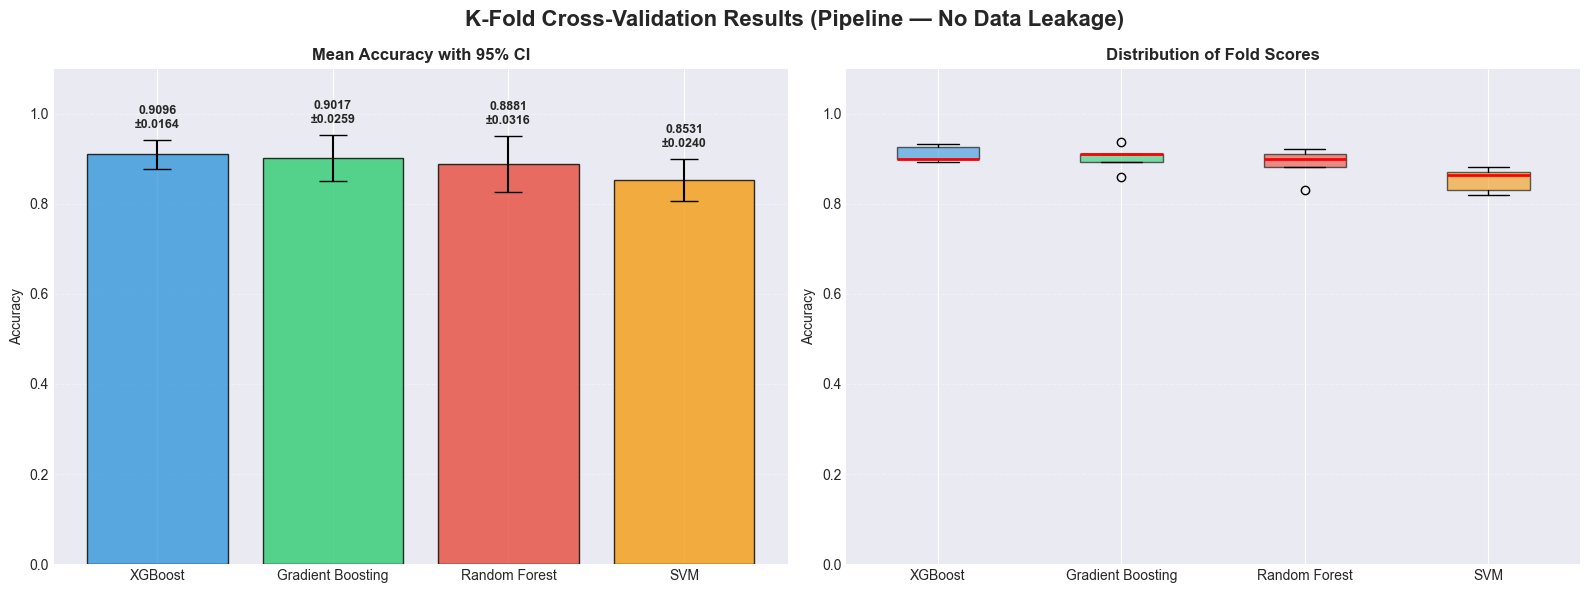

In [11]:
def visualize_cross_validation(cv_results):
    """Box plot + bar chart of cross-validation results."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('K-Fold Cross-Validation Results (Pipeline — No Data Leakage)',
                 fontsize=16, fontweight='bold')

    models_list = cv_results['Model'].tolist()
    mean_acc = cv_results['Mean_Accuracy'].tolist()
    std_dev = cv_results['Std_Dev'].tolist()
    fold_data = [cv_results.iloc[i]['Fold_Scores'] for i in range(len(cv_results))]

    colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12'][:len(models_list)]

    # Bar chart with error bars
    ax1 = axes[0]
    bars = ax1.bar(models_list, mean_acc, yerr=[s * 1.96 for s in std_dev],
                   capsize=10, color=colors, edgecolor='black', alpha=0.8)
    ax1.set_title('Mean Accuracy with 95% CI', fontweight='bold')
    ax1.set_ylabel('Accuracy')
    ax1.set_ylim(0, 1.1)
    ax1.grid(axis='y', alpha=0.3, linestyle='--')
    for bar, m, s in zip(bars, mean_acc, std_dev):
        ax1.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + s * 1.96 + 0.02,
                 f'{m:.4f}\n±{s:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

    # Box plot
    ax2 = axes[1]
    bp = ax2.boxplot(fold_data, labels=models_list, patch_artist=True,
                     medianprops=dict(color='red', linewidth=2))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax2.set_title('Distribution of Fold Scores', fontweight='bold')
    ax2.set_ylabel('Accuracy')
    ax2.set_ylim(0, 1.1)
    ax2.grid(axis='y', alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.show()

visualize_cross_validation(cv_results)

## 8. Model Evaluation

In [12]:
def evaluate_models(models, predictions, y_test, encoders):
    """
    Evaluate all models: accuracy, precision, recall, F1-score,
    and per-class classification reports.
    """
    print("=" * 80)
    print("MODEL EVALUATION")
    print("=" * 80)

    rows = []
    for name, y_pred in predictions.items():
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

        print(f"\n{'=' * 60}")
        print(f"{name}")
        print(f"{'=' * 60}")
        print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
        if 'target' in encoders:
            print(classification_report(y_test, y_pred,
                                        target_names=encoders['target'].classes_, zero_division=0))
        else:
            print(classification_report(y_test, y_pred, zero_division=0))

        rows.append({'Model': name, 'Accuracy': acc, 'Precision': prec,
                     'Recall': rec, 'F1-Score': f1})

    comparison_df = pd.DataFrame(rows).sort_values('Accuracy', ascending=False)

    print(f"\n{'=' * 80}")
    print("MODEL COMPARISON (sorted by accuracy)")
    print(f"{'=' * 80}")
    print(comparison_df.to_string(index=False))

    best_name = comparison_df.iloc[0]['Model']
    print(f"\nBest model: {best_name} — accuracy {comparison_df.iloc[0]['Accuracy']:.4f}")
    print("=" * 80)

    return comparison_df, best_name

comparison_df, best_model_name = evaluate_models(models, predictions, y_test, encoders)

MODEL EVALUATION

SVM
Accuracy: 0.8684 | Precision: 0.8681 | Recall: 0.8684 | F1: 0.8681
              precision    recall  f1-score   support

        fast       0.87      0.90      0.89        90
      medium       0.81      0.79      0.80        81
        slow       0.91      0.91      0.91        95

    accuracy                           0.87       266
   macro avg       0.87      0.87      0.87       266
weighted avg       0.87      0.87      0.87       266


Random Forest
Accuracy: 0.8985 | Precision: 0.8981 | Recall: 0.8985 | F1: 0.8980
              precision    recall  f1-score   support

        fast       0.94      0.93      0.94        90
      medium       0.85      0.81      0.83        81
        slow       0.90      0.94      0.92        95

    accuracy                           0.90       266
   macro avg       0.90      0.89      0.90       266
weighted avg       0.90      0.90      0.90       266


Gradient Boosting
Accuracy: 0.8872 | Precision: 0.8867 | Recall: 0

## 9. Visualization of Results

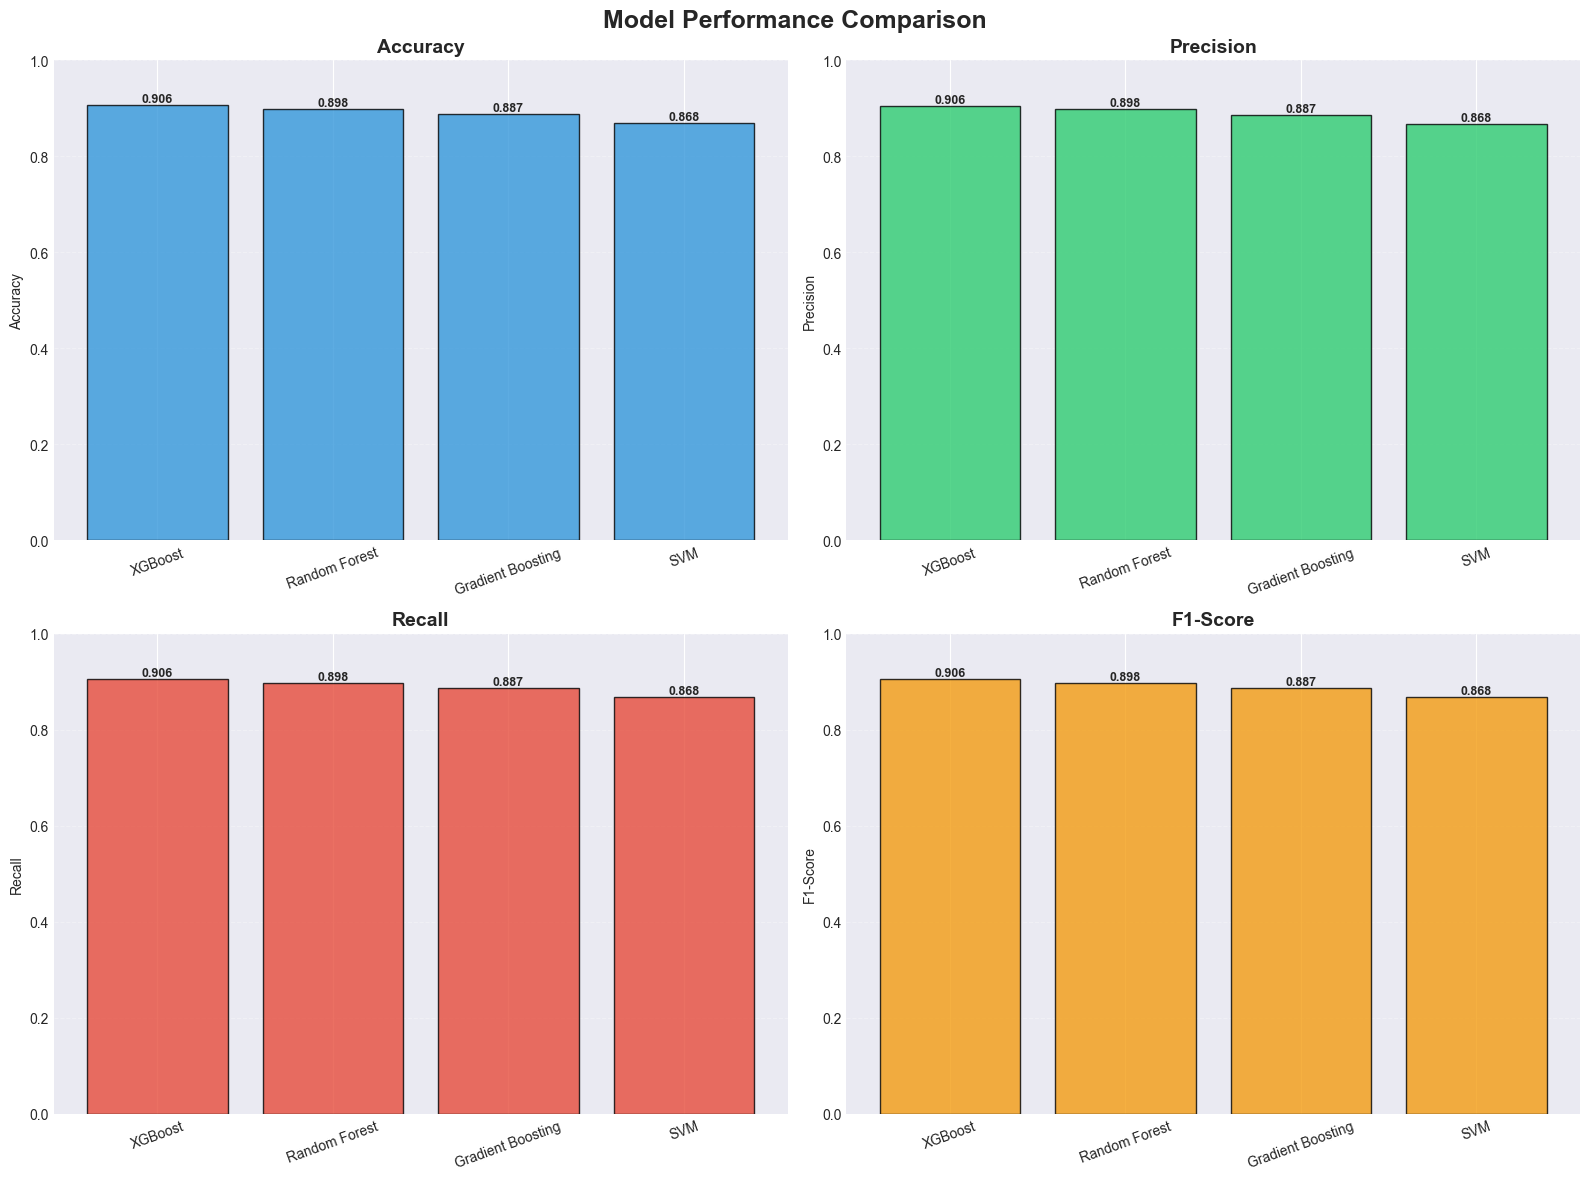

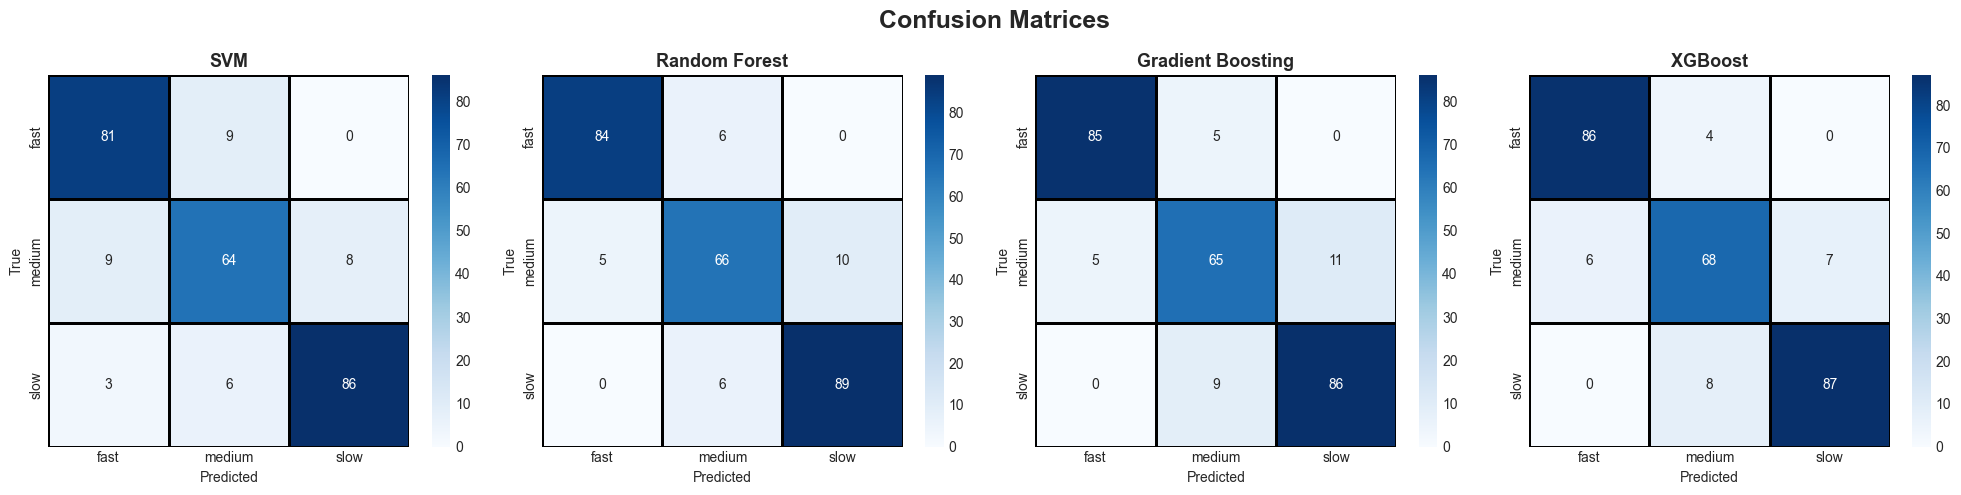

In [13]:
def visualize_results(comparison_df, predictions, y_test, encoders):
    """Metric bar charts + confusion matrices for all models."""
    # 1. Metric comparison
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Model Performance Comparison', fontsize=18, fontweight='bold')
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

    for idx, (metric, color) in enumerate(zip(metrics, colors)):
        ax = axes[idx // 2, idx % 2]
        bars = ax.bar(comparison_df['Model'], comparison_df[metric],
                      color=color, edgecolor='black', alpha=0.8)
        ax.set_title(metric, fontweight='bold', fontsize=14)
        ax.set_ylabel(metric)
        ax.set_ylim(0, 1.0)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.tick_params(axis='x', rotation=20)
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2., h,
                    f'{h:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

    plt.tight_layout()
    plt.show()

    # 2. Confusion matrices
    n = len(predictions)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]
    fig.suptitle('Confusion Matrices', fontsize=18, fontweight='bold')
    labels = encoders['target'].classes_ if 'target' in encoders else np.unique(y_test)

    for idx, (name, y_pred) in enumerate(predictions.items()):
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                    xticklabels=labels, yticklabels=labels,
                    linewidths=1, linecolor='black')
        axes[idx].set_title(name, fontweight='bold', fontsize=13)
        axes[idx].set_ylabel('True')
        axes[idx].set_xlabel('Predicted')

    plt.tight_layout()
    plt.show()

visualize_results(comparison_df, predictions, y_test, encoders)

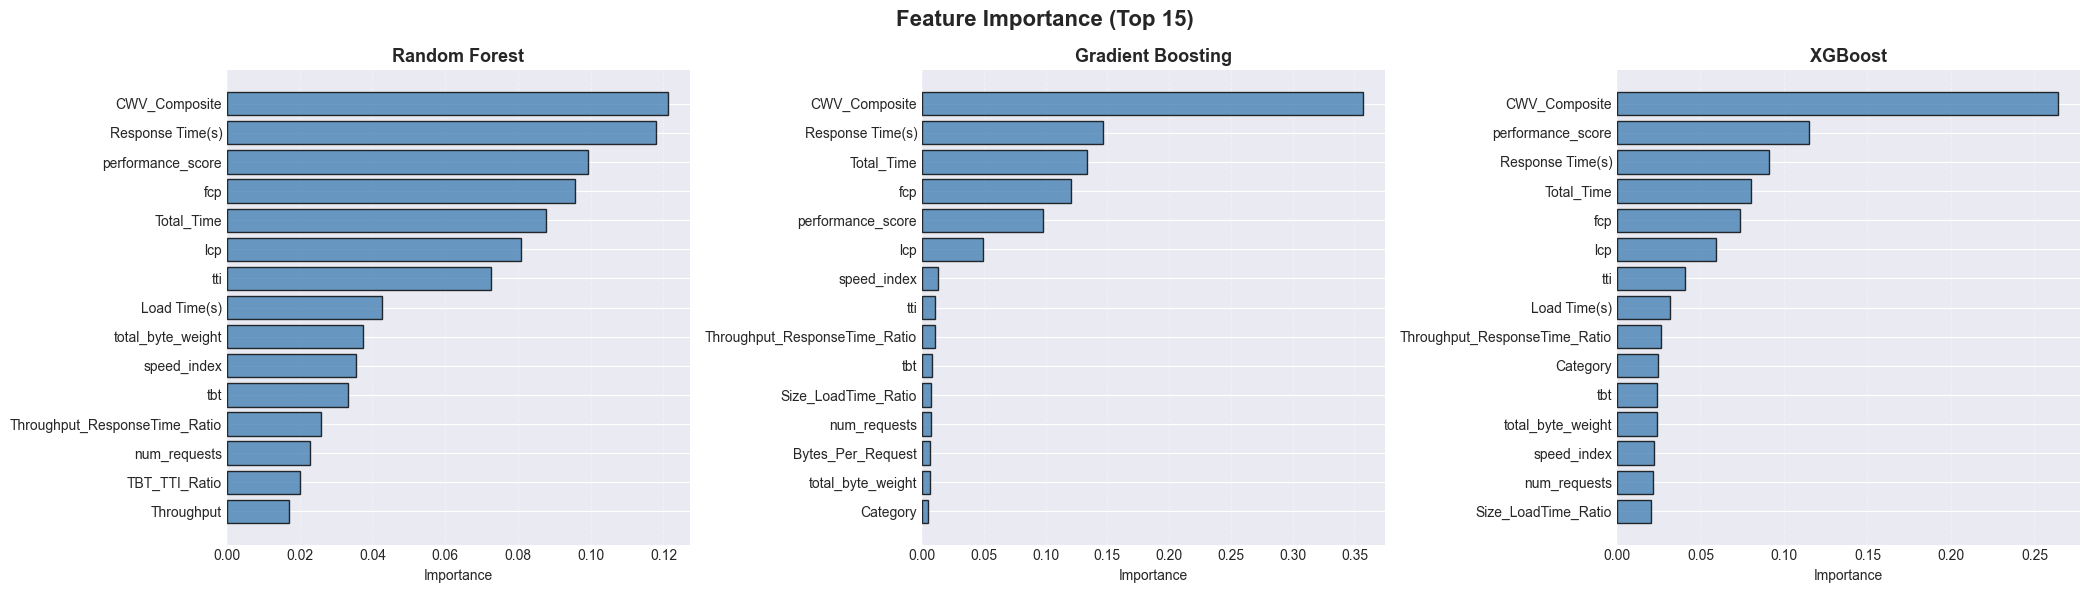

In [14]:
def plot_feature_importance(models, feature_names):
    """Feature importance for all tree-based models."""
    tree_models = {n: m for n, m in models.items() if hasattr(m, 'feature_importances_')}
    if not tree_models:
        print("No tree-based models available.")
        return

    n = len(tree_models)
    fig, axes = plt.subplots(1, n, figsize=(7 * n, 6))
    if n == 1:
        axes = [axes]
    fig.suptitle('Feature Importance (Top 15)', fontsize=16, fontweight='bold')

    for idx, (name, model) in enumerate(tree_models.items()):
        imp = model.feature_importances_
        fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': imp})
        fi_df = fi_df.sort_values('Importance', ascending=True).tail(15)

        axes[idx].barh(fi_df['Feature'], fi_df['Importance'],
                       color='steelblue', edgecolor='black', alpha=0.8)
        axes[idx].set_title(name, fontweight='bold', fontsize=13)
        axes[idx].set_xlabel('Importance')
        axes[idx].grid(axis='x', alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.show()

plot_feature_importance(models, feature_names_engineered)

## 10. Model Export

In [15]:
def export_model(model, model_name, scaler, encoders, feature_names,
                 comparison_df, tuned_results):
    """Export best model with all preprocessing objects and metadata."""
    print("=" * 80)
    print("MODEL EXPORT")
    print("=" * 80)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    metrics_row = comparison_df[comparison_df['Model'] == model_name].to_dict('records')[0]
    best_params = tuned_results[model_name][1]

    model_package = {
        'model': model,
        'model_name': model_name,
        'scaler': scaler,
        'encoders': encoders,
        'feature_names': feature_names,
        'metrics': metrics_row,
        'best_hyperparameters': best_params,
        'timestamp': timestamp,
    }

    filename = f'best_model_{model_name.lower().replace(" ", "_")}_{timestamp}.joblib'
    joblib.dump(model_package, filename)

    print(f"\nExported: {filename}")
    print(f"  Model:      {model_name}")
    print(f"  Features:   {len(feature_names)}")
    print(f"  Accuracy:   {metrics_row['Accuracy']:.4f}")
    print(f"  F1-Score:   {metrics_row['F1-Score']:.4f}")
    print(f"  Hyperparams: {best_params}")
    print("=" * 80)

    return filename

best_model = models[best_model_name]
model_file = export_model(
    best_model, best_model_name, scaler, encoders,
    feature_names_engineered, comparison_df, tuned_results
)

MODEL EXPORT

Exported: best_model_xgboost_20260225_114145.joblib
  Model:      XGBoost
  Features:   22
  Accuracy:   0.9060
  F1-Score:   0.9058
  Hyperparams: {'subsample': 0.8, 'reg_lambda': 1.5, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


## 11. Model Loading Utility

In [16]:
def load_and_predict(model_filename, new_data):
    """
    Load a saved model package and make predictions on new data.
    """
    pkg = joblib.load(model_filename)
    model = pkg['model']
    scaler = pkg['scaler']
    encoders = pkg['encoders']

    print(f"Loaded: {pkg['model_name']} (accuracy {pkg['metrics']['Accuracy']:.4f})")

    new_data_scaled = scaler.transform(new_data)
    preds = model.predict(new_data_scaled)

    if 'target' in encoders:
        preds = encoders['target'].inverse_transform(preds)

    return preds

# Example (uncomment to test):
# sample_predictions = load_and_predict(model_file, X_test[:5])
# print(f"Sample predictions: {sample_predictions}")
print("Model loading function defined — use load_and_predict(filename, data)")

Model loading function defined — use load_and_predict(filename, data)


## 12. Learning Curves & Statistical Significance Testing

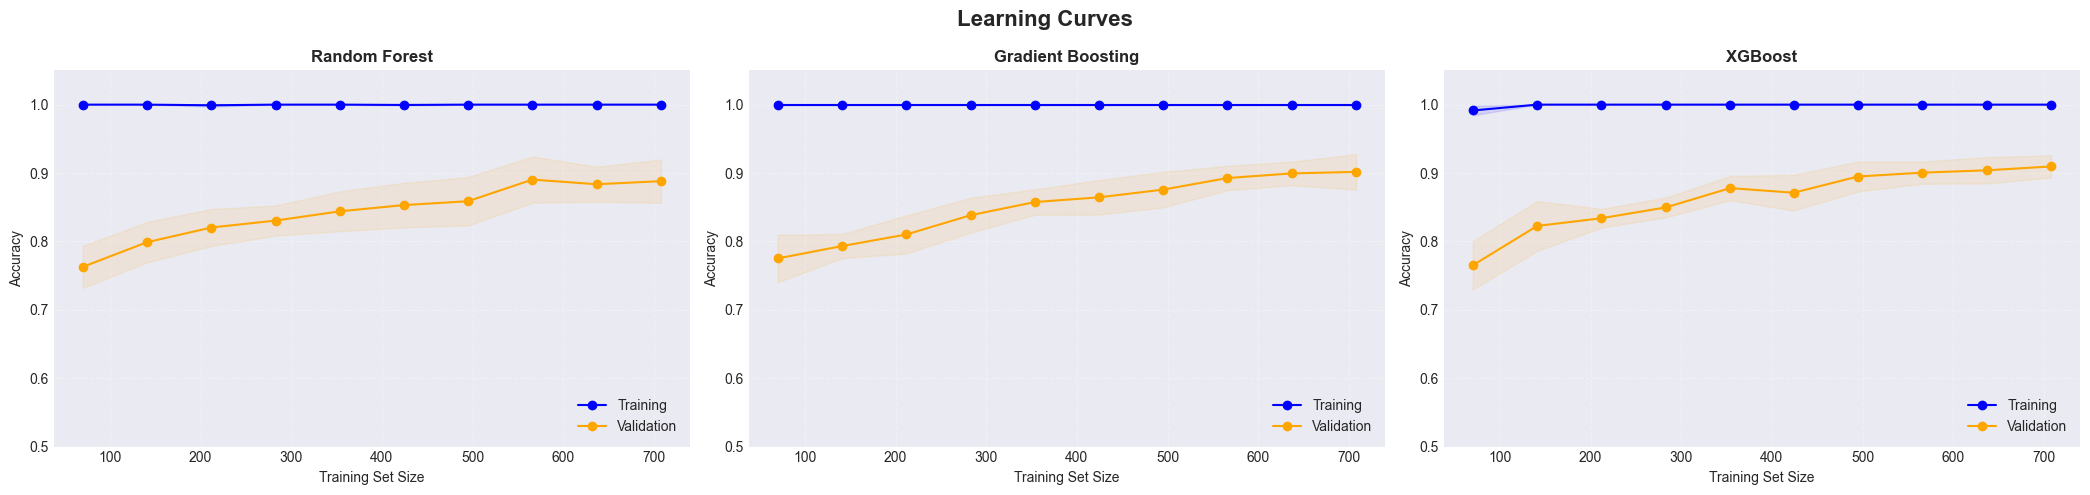

In [17]:
def plot_learning_curves(X, y, models_dict, cv_folds=5, random_state=42):
    """
    Learning curves: training vs validation accuracy as a function of
    training set size. Helps diagnose overfitting / underfitting.
    """
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
    top_models = {n: m for n, m in models_dict.items() if n != 'SVM'}  # SVM is slow

    fig, axes = plt.subplots(1, len(top_models), figsize=(7 * len(top_models), 5))
    if len(top_models) == 1:
        axes = [axes]
    fig.suptitle('Learning Curves', fontsize=16, fontweight='bold')

    for idx, (name, model) in enumerate(top_models.items()):
        from sklearn.base import clone
        pipe = Pipeline([('scaler', RobustScaler()), ('model', clone(model))])

        train_sizes, train_scores, val_scores = learning_curve(
            pipe, X, y, cv=cv, scoring='accuracy',
            train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1,
            random_state=random_state
        )

        train_mean = train_scores.mean(axis=1)
        train_std = train_scores.std(axis=1)
        val_mean = val_scores.mean(axis=1)
        val_std = val_scores.std(axis=1)

        ax = axes[idx]
        ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
        ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='orange')
        ax.plot(train_sizes, train_mean, 'o-', color='blue', label='Training')
        ax.plot(train_sizes, val_mean, 'o-', color='orange', label='Validation')
        ax.set_title(name, fontweight='bold')
        ax.set_xlabel('Training Set Size')
        ax.set_ylabel('Accuracy')
        ax.legend(loc='lower right')
        ax.grid(alpha=0.3, linestyle='--')
        ax.set_ylim(0.5, 1.05)

    plt.tight_layout()
    plt.show()

plot_learning_curves(X_engineered, y, models)

In [18]:
def statistical_significance_tests(fold_scores, predictions, y_test):
    """
    Statistical significance tests:
    1. Friedman test — are there significant differences among all models?
    2. Pairwise Wilcoxon signed-rank tests on CV fold scores.
    3. McNemar's test on test-set predictions (pairwise).
    """
    print("=" * 80)
    print("STATISTICAL SIGNIFICANCE TESTING")
    print("=" * 80)

    model_names = list(fold_scores.keys())
    scores_arrays = [fold_scores[n] for n in model_names]

    # 1. Friedman test
    print("\n1. Friedman Test (H0: all models perform equally)")
    print("-" * 60)
    if len(scores_arrays) >= 3:
        stat, p_val = friedmanchisquare(*scores_arrays)
        print(f"   Chi-squared = {stat:.4f}, p-value = {p_val:.6f}")
        if p_val < 0.05:
            print("   Result: REJECT H0 — significant difference exists (p < 0.05)")
        else:
            print("   Result: FAIL TO REJECT H0 — no significant difference (p >= 0.05)")
    else:
        print("   Need >= 3 models for Friedman test")

    # 2. Pairwise Wilcoxon signed-rank tests on fold scores
    print("\n2. Pairwise Wilcoxon Signed-Rank Tests (CV fold scores)")
    print("-" * 60)
    print(f"   {'Comparison':<35} {'Statistic':>10} {'p-value':>10} {'Significant':>12}")
    print("   " + "-" * 67)
    for i in range(len(model_names)):
        for j in range(i + 1, len(model_names)):
            n1, n2 = model_names[i], model_names[j]
            try:
                stat, p_val = wilcoxon(fold_scores[n1], fold_scores[n2])
                sig = "Yes*" if p_val < 0.05 else "No"
                print(f"   {n1} vs {n2:<20} {stat:>10.4f} {p_val:>10.6f} {sig:>12}")
            except Exception as e:
                print(f"   {n1} vs {n2:<20} — Could not compute: {e}")

    # 3. McNemar's test on test predictions
    print("\n3. McNemar's Test (test-set predictions)")
    print("-" * 60)
    print(f"   {'Comparison':<35} {'Chi-sq':>10} {'p-value':>10} {'Significant':>12}")
    print("   " + "-" * 67)
    from scipy.stats import chi2

    for i in range(len(model_names)):
        for j in range(i + 1, len(model_names)):
            n1, n2 = model_names[i], model_names[j]
            y1 = predictions[n1]
            y2 = predictions[n2]

            # Build contingency: correct1&wrong2 vs wrong1&correct2
            c1 = (y1 == y_test)
            c2 = (y2 == y_test)
            b = np.sum(c1 & ~c2)  # model1 correct, model2 wrong
            c = np.sum(~c1 & c2)  # model1 wrong, model2 correct

            if b + c == 0:
                print(f"   {n1} vs {n2:<20}       N/A        N/A   Identical")
                continue

            # McNemar with continuity correction
            chi_sq = (abs(b - c) - 1) ** 2 / (b + c)
            p_val = 1 - chi2.cdf(chi_sq, df=1)
            sig = "Yes*" if p_val < 0.05 else "No"
            print(f"   {n1} vs {n2:<20} {chi_sq:>10.4f} {p_val:>10.6f} {sig:>12}")

    print("\n   * Significant at α = 0.05")
    print("=" * 80)

statistical_significance_tests(fold_scores, predictions, y_test)

STATISTICAL SIGNIFICANCE TESTING

1. Friedman Test (H0: all models perform equally)
------------------------------------------------------------
   Chi-squared = 10.7143, p-value = 0.013376
   Result: REJECT H0 — significant difference exists (p < 0.05)

2. Pairwise Wilcoxon Signed-Rank Tests (CV fold scores)
------------------------------------------------------------
   Comparison                           Statistic    p-value  Significant
   -------------------------------------------------------------------
   SVM vs Random Forest            0.0000   0.062500           No
   SVM vs Gradient Boosting        0.0000   0.062500           No
   SVM vs XGBoost                  0.0000   0.062500           No
   Random Forest vs Gradient Boosting        3.0000   0.250000           No
   Random Forest vs XGBoost                  0.0000   0.125000           No
   Gradient Boosting vs XGBoost                  4.5000   0.500000           No

3. McNemar's Test (test-set predictions)
-----------

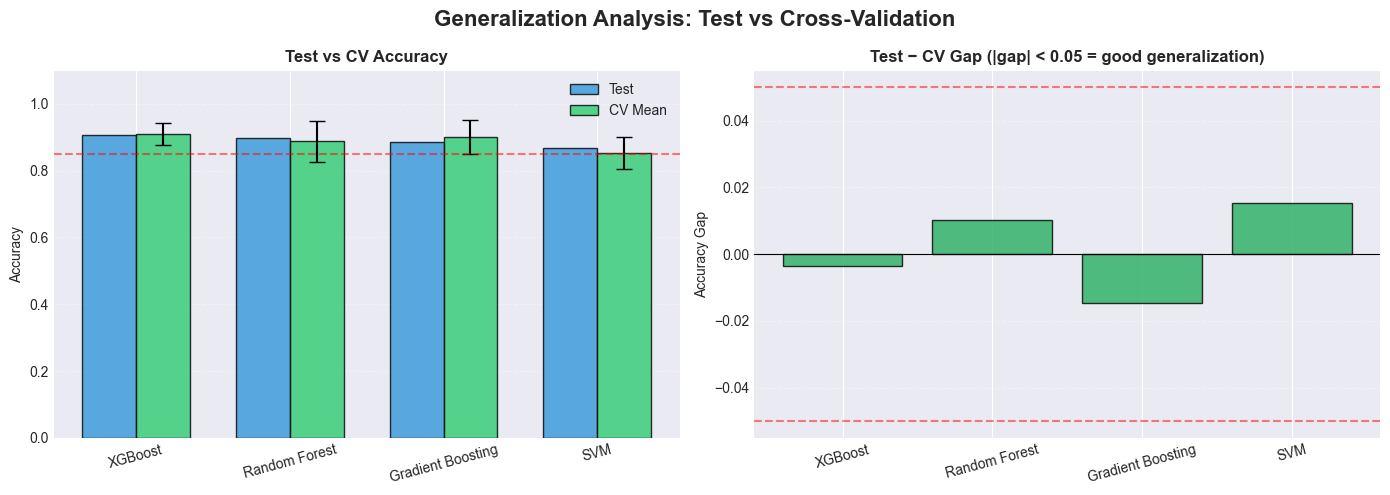

In [19]:
def visualize_test_vs_cv(comparison_df, cv_results):
    """Compare test accuracy vs cross-validation accuracy for generalization analysis."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Generalization Analysis: Test vs Cross-Validation', fontsize=16, fontweight='bold')

    # Models present in both test and CV results
    common = comparison_df['Model'].tolist()
    test_accs = [comparison_df[comparison_df['Model'] == m]['Accuracy'].values[0] for m in common]
    cv_accs = [cv_results[cv_results['Model'] == m]['Mean_Accuracy'].values[0] for m in common]
    cv_stds = [cv_results[cv_results['Model'] == m]['Std_Dev'].values[0] for m in common]

    # Bar chart comparison
    ax1 = axes[0]
    x = np.arange(len(common))
    w = 0.35
    ax1.bar(x - w/2, test_accs, w, label='Test', color='#3498db', edgecolor='black', alpha=0.8)
    ax1.bar(x + w/2, cv_accs, w, yerr=[s*1.96 for s in cv_stds], capsize=6,
            label='CV Mean', color='#2ecc71', edgecolor='black', alpha=0.8)
    ax1.set_xticks(x)
    ax1.set_xticklabels(common, rotation=15)
    ax1.set_ylabel('Accuracy')
    ax1.set_title('Test vs CV Accuracy', fontweight='bold')
    ax1.legend()
    ax1.set_ylim(0, 1.1)
    ax1.axhline(y=0.85, color='red', linestyle='--', alpha=0.5, label='85% threshold')
    ax1.grid(axis='y', alpha=0.3, linestyle='--')

    # Gap analysis
    ax2 = axes[1]
    gaps = [t - c for t, c in zip(test_accs, cv_accs)]
    colors = ['#27ae60' if abs(g) < 0.05 else '#e67e22' for g in gaps]
    ax2.bar(common, gaps, color=colors, edgecolor='black', alpha=0.8)
    ax2.axhline(y=0, color='black', linewidth=0.8)
    ax2.axhline(y=0.05, color='red', linestyle='--', alpha=0.5)
    ax2.axhline(y=-0.05, color='red', linestyle='--', alpha=0.5)
    ax2.set_title('Test − CV Gap (|gap| < 0.05 = good generalization)', fontweight='bold')
    ax2.set_ylabel('Accuracy Gap')
    ax2.tick_params(axis='x', rotation=15)
    ax2.grid(axis='y', alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.show()

visualize_test_vs_cv(comparison_df, cv_results)

In [22]:
print("=" * 80)
print("PHASE 1 SUMMARY")
print("=" * 80)

print("\nCompleted steps:")
print("  1. Data loading (885 URLs, cleaned labels)")
print("  2. Preprocessing (imputation, encoding, zero-variance removal)")
print("  3. Feature engineering ({} features)".format(len(feature_names_engineered)))
print("  4. Hyperparameter tuning (RandomizedSearchCV, 50 iterations)")
print("  5. Model evaluation (4 models: SVM, RF, GB, XGBoost)")
print("  6. Cross-validation (5-fold, Pipeline — no data leakage)")
print("  7. Statistical significance testing (Friedman, Wilcoxon, McNemar)")
print("  8. Learning curves (overfitting/underfitting diagnosis)")

print(f"\nBest model: {best_model_name}")
best_row = comparison_df[comparison_df['Model'] == best_model_name].iloc[0]
print(f"  Test accuracy:  {best_row['Accuracy']:.4f}")
print(f"  Test F1-score:  {best_row['F1-Score']:.4f}")

best_cv = cv_results[cv_results['Model'] == best_model_name].iloc[0]
print(f"  CV accuracy:    {best_cv['Mean_Accuracy']:.4f} ± {best_cv['Std_Dev']:.4f}")

print(f"\nExported: {model_file}")

print("\nModel comparison:")
print(comparison_df.to_string(index=False))

print("\nNext steps:")
print("  Phase 2 — Prescriptive optimization (SciPy differential evolution)")
print("  Phase 3 — Explainability analysis (SHAP + LIME)")
print("=" * 80)

PHASE 1 SUMMARY

Completed steps:
  1. Data loading (885 URLs, cleaned labels)
  2. Preprocessing (imputation, encoding, zero-variance removal)
  3. Feature engineering (22 features)
  4. Hyperparameter tuning (RandomizedSearchCV, 50 iterations)
  5. Model evaluation (4 models: SVM, RF, GB, XGBoost)
  6. Cross-validation (5-fold, Pipeline — no data leakage)
  7. Statistical significance testing (Friedman, Wilcoxon, McNemar)
  8. Learning curves (overfitting/underfitting diagnosis)

Best model: XGBoost
  Test accuracy:  0.9060
  Test F1-score:  0.9058
  CV accuracy:    0.9096 ± 0.0164

Exported: best_model_xgboost_20260225_114145.joblib

Model comparison:
            Model  Accuracy  Precision   Recall  F1-Score
          XGBoost  0.906015   0.905662 0.906015  0.905781
    Random Forest  0.898496   0.898069 0.898496  0.898043
Gradient Boosting  0.887218   0.886738 0.887218  0.886905
              SVM  0.868421   0.868129 0.868421  0.868147

Next steps:
  Phase 2 — Prescriptive optimizat

In [26]:
# Temporary extraction cell — can be removed


SVM (CV=0.8579): {'kernel': 'rbf', 'gamma': 'auto', 'class_weight': 'balanced', 'C': 10}
Random Forest (CV=0.8869): {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20, 'class_weight': 'balanced'}
Gradient Boosting (CV=0.9014): {'subsample': 0.8, 'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 3, 'learning_rate': 0.1}
XGBoost (CV=0.8966): {'subsample': 0.8, 'reg_lambda': 1.5, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
